In [1]:
# Importazione delle librerie necessarie

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score


# Caricamento del dataset

data = load_iris()

X = data.data # le caratteristiche

y = data.target # le etichette


# Divisione dei dati in set di addestramento e di test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Creazione del modello di classificazione

model = RandomForestClassifier(n_estimators=100, random_state=42)


# Addestramento del modello

model.fit(X_train, y_train)


# Predizione delle etichette per il set di test

predictions = model.predict(X_test)


# Calcolo dell'accuratezza del modello

accuracy = accuracy_score(y_test, predictions)

print(f'Accuracy: {accuracy:.2f}')

Accuracy: 1.00


senza rimozione outlier:

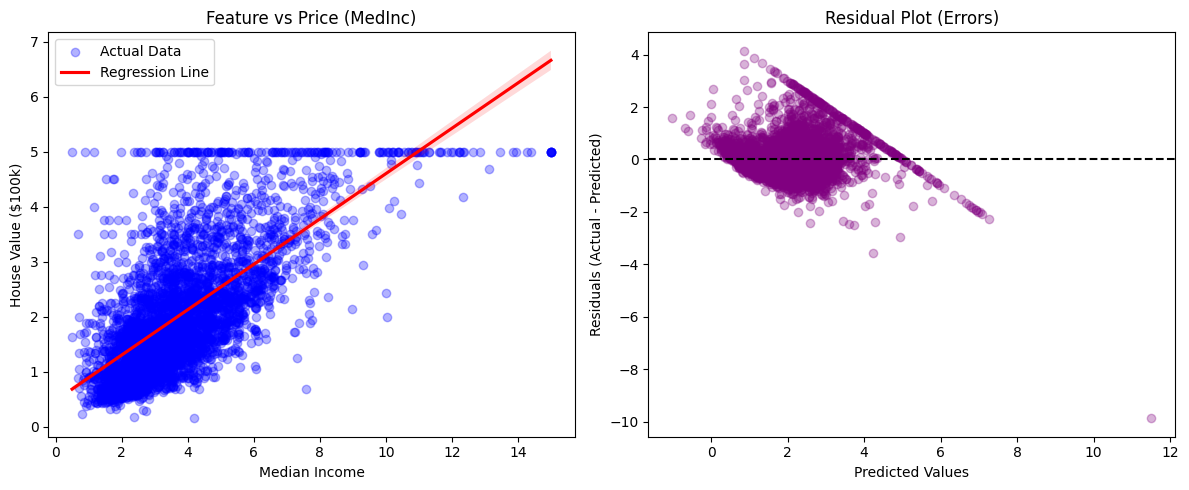

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

#Load Data
housing = fetch_california_housing()
X = housing.data
y = housing.target

#Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Train Model
model = LinearRegression()
model.fit(X_train, y_train)

#Predictions and Residuals
y_pred = model.predict(X_test)
residuals = y_test - y_pred

#PLOTTING
plt.figure(figsize=(12, 5))

#--- Plot 1: Regression Line (using 'Median Income' which is index 0) ---
plt.subplot(1, 2, 1)
#Plotting only the first feature (Median Income) vs Target
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.3, label='Actual Data')
#Fit a simple line just for this plot to visualize the trend
sns.regplot(x=X_test[:, 0], y=y_test, scatter=False, color='red', label='Regression Line')
plt.title('Feature vs Price (MedInc)')
plt.xlabel('Median Income')
plt.ylabel('House Value ($100k)')
plt.legend()

#--- Plot 2: Residual Plot ---
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, color='purple', alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--') # Zero error line
plt.title('Residual Plot (Errors)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')

plt.tight_layout()
plt.show()

con rimozione outlier

mse: 0.47310162544208


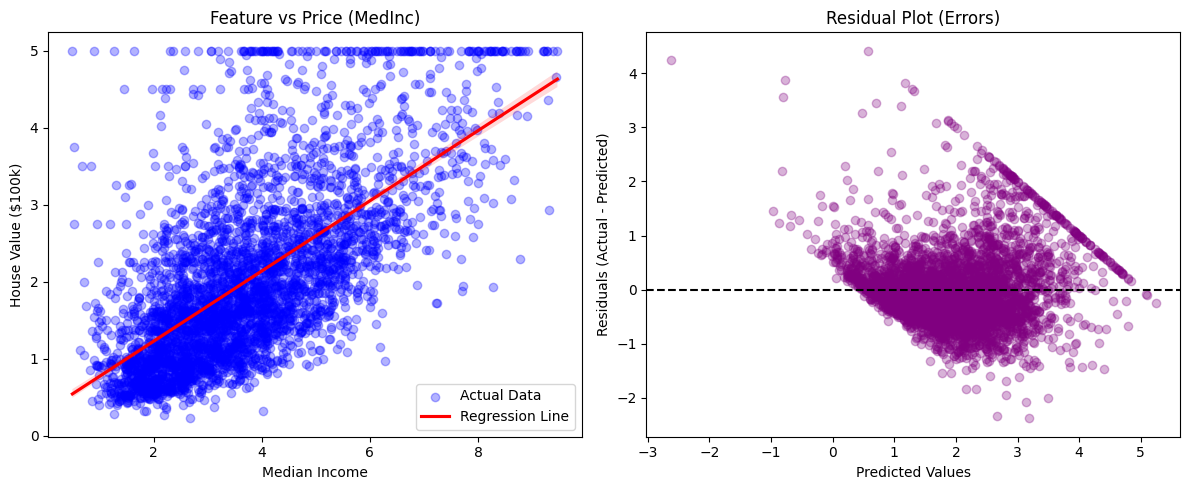

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

#Load Data
housing = fetch_california_housing()
X = housing.data
y = housing.target

#Applicare rimozione outlier con z score = 3
import numpy as np

# Calcolo media e deviazione standard per ogni colonna
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)

# Calcolo z-score manualmente a tutti i dati
z_scores = np.abs((X - mean) / std)

# Teniamo solo le righe con |z| < 3 dev std per tutte le feature
filtered_entries = (z_scores < 3).all(axis=1)

X_clean = X[filtered_entries]
y_clean = y[filtered_entries]


#split dei dati puliti
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)


#Train Model
model = LinearRegression()
model.fit(X_train, y_train)

#Predictions and Residuals
y_pred = model.predict(X_test)
residuals = y_test - y_pred

#---Mean squared error
mse = mean_squared_error(y_test, y_pred)
print("mse:" , mse)

#PLOTTING
plt.figure(figsize=(12, 5))

#--- Plot 1: Regression Line (using 'Median Income' which is index 0) ---
plt.subplot(1, 2, 1)
#Plotting only the first feature (Median Income) vs Target
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.3, label='Actual Data')
#Fit a simple line just for this plot to visualize the trend
sns.regplot(x=X_test[:, 0], y=y_test, scatter=False, color='red', label='Regression Line')
plt.title('Feature vs Price (MedInc)')
plt.xlabel('Median Income')
plt.ylabel('House Value ($100k)')
plt.legend()

#--- Plot 2: Residual Plot ---
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, color='purple', alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--') # Zero error line
plt.title('Residual Plot (Errors)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')

plt.tight_layout()
plt.show()

## Logistic regression

In [6]:
# Importazione delle librerie necessarie

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score


# Caricamento del dataset

data = load_iris()

X = data.data  # le caratteristiche

y = data.target  # le etichette


# Divisione dei dati in set di addestramento e di test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Creazione del modello di classificazione

model = LogisticRegression()


# Addestramento del modello

model.fit(X_train, y_train)


# Predizione delle etichette per il set di test

predictions = model.predict(X_test)


# Calcolo dell'accuratezza del modello

accuracy = accuracy_score(y_test, predictions)

print(f'Accuracy: {accuracy:.2f}')

Accuracy: 1.00
